In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
import joblib

In [3]:
# Load scaler
scaler = joblib.load('scaler.pkl')

In [4]:
# Load model
file = 'best_autoencoder_model.keras'
model = load_model(file)

In [5]:
df_train = pd.read_csv('train_dataset.csv', index_col=0)
df_test = pd.read_csv('test_dataset.csv', index_col=0)

In [6]:
df_train.index = pd.to_datetime(df_train.index)
df_test.index = pd.to_datetime(df_test.index)

In [7]:
df_train.sort_index(ascending=False, inplace=True)
df_test.sort_index(ascending=True, inplace=True)

df_train.head(3)

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
time,,,,,
2026-06-10 08:30:23.537,62.0,57.7,4.3,0.36,11.8
2026-06-10 08:30:11.736,66.2,59.9,6.3,0.61,10.3
2026-06-10 08:30:01.435,71.4,52.8,18.6,1.96,9.5


In [8]:
df_test.head(3)

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
time,,,,,
2026-06-10 07:17:17.152,69.5,56.4,13.1,0.77,17.1
2026-06-10 07:17:48.897,68.0,50.7,17.3,1.42,12.2
2026-06-10 07:18:06.570,69.6,58.8,10.8,0.61,17.6


In [9]:
df_test.head(3)

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
time,,,,,
2026-06-10 07:17:17.152,69.5,56.4,13.1,0.77,17.1
2026-06-10 07:17:48.897,68.0,50.7,17.3,1.42,12.2
2026-06-10 07:18:06.570,69.6,58.8,10.8,0.61,17.6


In [10]:
train_transformed = scaler.transform(df_train)
test_transformed = scaler.transform(df_test)

In [11]:
recon_train = model.predict(train_transformed)
recon_train_loss = np.mean(np.abs(train_transformed - recon_train), axis=1)
print("recon_train_loss:", recon_train_loss[:5])
print("Average reconstruction loss for training set:", np.mean(recon_train_loss))

recon_test = model.predict(test_transformed)
recon_test_loss = np.mean(np.abs(test_transformed - recon_test), axis=1)
print("recon_test_loss:", recon_test_loss[:5])
print("Average reconstruction loss for test set:", np.mean(recon_test_loss))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
recon_train_loss: [1.02911774 0.91281412 0.5250037  0.55400828 0.72938758]
Average reconstruction loss for training set: 0.7106643188284875
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
recon_test_loss: [0.41731173 0.47892358 0.75509114 0.94755995 0.44168232]
Average reconstruction loss for test set: 0.6979461642663817


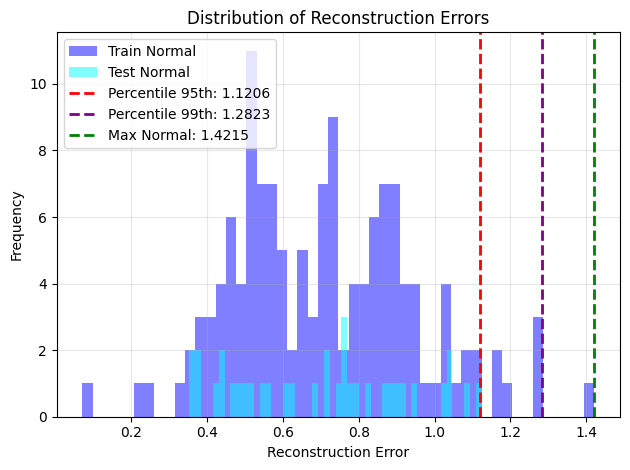

In [12]:
max_normal = max(np.max(recon_train_loss), np.max(recon_test_loss))
percentile_95_normal = np.percentile(recon_train_loss, 95)
percentile_99_normal = np.percentile(recon_train_loss, 99)

# Plot distribusi histogram
plt.hist(recon_train_loss, bins=50, alpha=0.5, label='Train Normal', color='blue')
plt.hist(recon_test_loss, bins=50, alpha=0.5, label='Test Normal', color='cyan')
plt.axvline(percentile_95_normal, color='red', linestyle='--', linewidth=2, label=f'Percentile 95th: {percentile_95_normal:.4f}')
plt.axvline(percentile_99_normal, color='purple', linestyle='--', linewidth=2, label=f'Percentile 99th: {percentile_99_normal:.4f}')
plt.axvline(max_normal, color='green', linestyle='--', linewidth=2, label=f'Max Normal: {max_normal:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# choose threshold
threshold = percentile_95_normal
print("Chosen threshold:", threshold)

Chosen threshold: 1.1205691551933008


In [14]:
features = df_train.columns.to_list()

df_train_recon = scaler.inverse_transform(recon_train)
df_train_recon = pd.DataFrame(df_train_recon, columns=features, index=df_train.index)
df_train_recon.head()

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
time,,,,,
2026-06-10 08:30:23.537,67.987434,55.275574,12.659626,1.150839,11.860663
2026-06-10 08:30:11.736,68.060806,55.270893,12.703837,1.138773,12.010587
2026-06-10 08:30:01.435,67.545685,53.276787,16.082439,1.935385,13.743038
2026-06-10 08:29:51.934,68.319420,55.402725,13.600565,1.103565,13.260623
2026-06-10 08:29:32.934,68.227318,55.365150,13.093857,1.081380,12.849470


In [34]:
def comparison_plot(df, df_recon):
    features = df.columns.to_list()

    fig, axes = plt.subplots(5, 2, figsize=(14, 12))

    axes = np.array(axes).flatten()

    for i, feature in enumerate(features):

        axes[i].plot(
            df.index,
            df.iloc[:, i],
            label='Actual'
        )

        axes[i].plot(
            df_recon.index,
            df_recon.iloc[:, i],
            label='Reconstructed'
        )

        axes[i].set_title(feature)
        axes[i].legend()
        axes[i].grid(True)

    # Hapus subplot kosong jika jumlah fitur ganjil
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

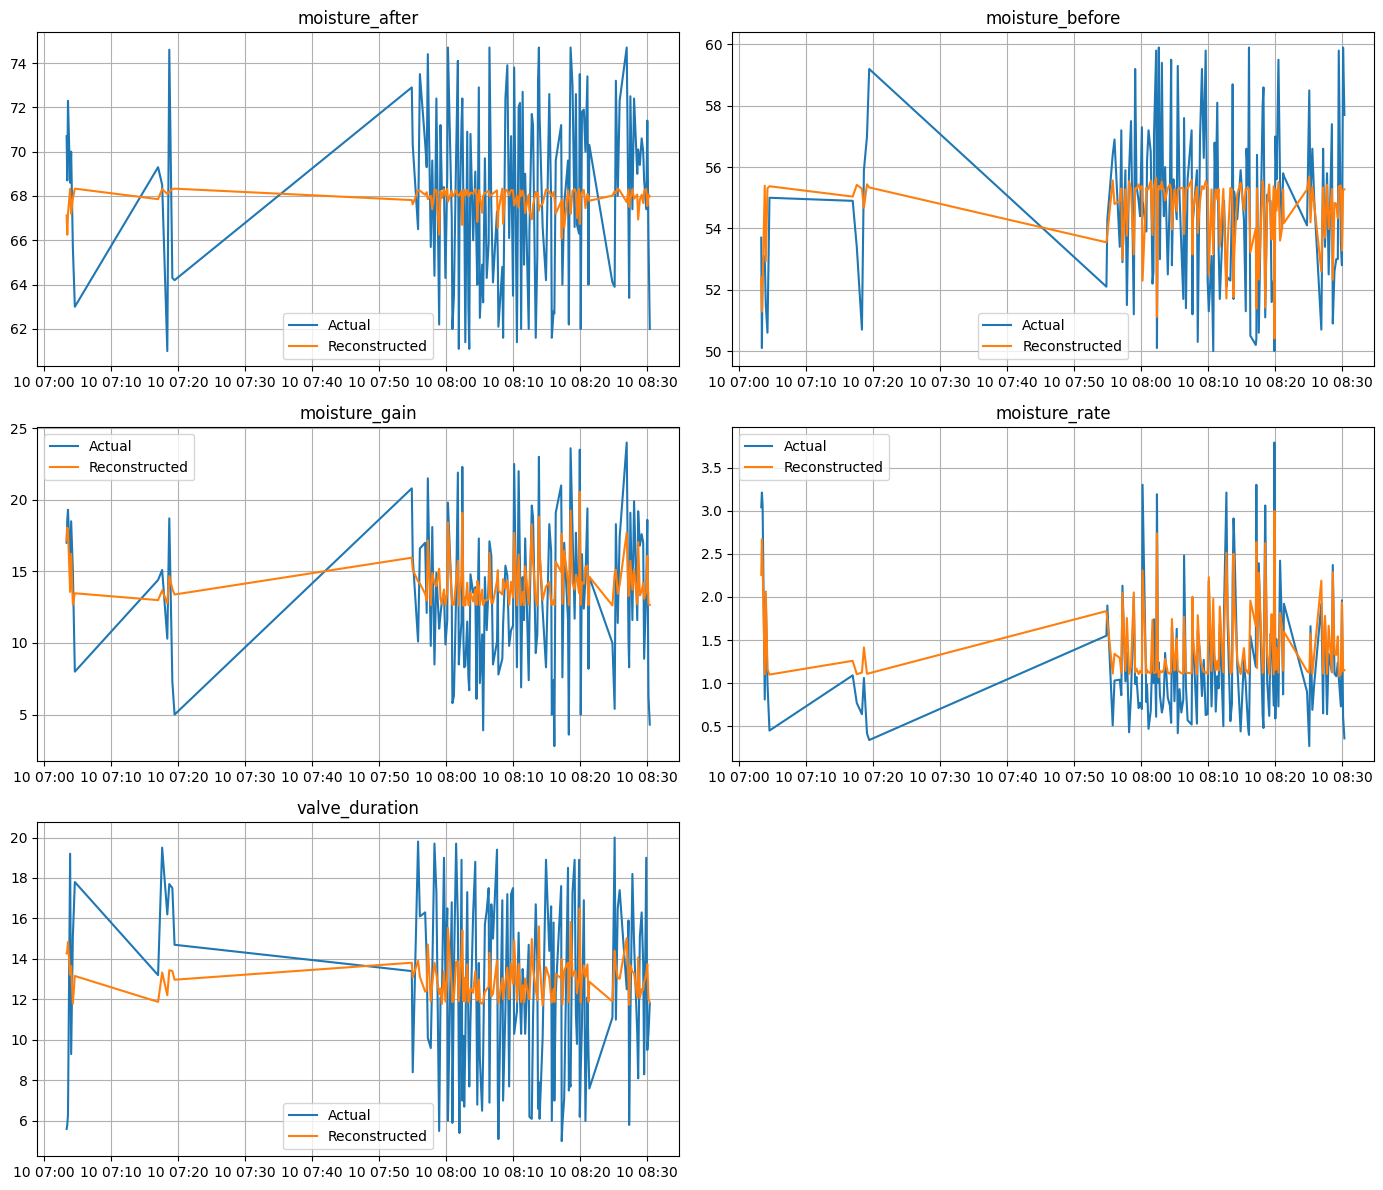

In [16]:
comparison_plot(df_train, df_train_recon)

In [17]:
df_test_recon = scaler.inverse_transform(recon_test)
df_test_recon = pd.DataFrame(df_test_recon, columns=features, index=df_test.index)
df_test_recon.head()

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
time,,,,,
2026-06-10 07:17:17.152,68.322021,55.385227,13.565676,1.109815,13.184079
2026-06-10 07:17:48.897,67.187096,53.674606,14.735833,1.786587,12.555771
2026-06-10 07:18:06.570,68.268234,55.521084,14.169332,1.121381,13.717158
2026-06-10 07:19:13.030,66.096497,52.925976,15.419178,2.138345,12.321063
2026-06-10 07:54:38.833,66.883301,53.095524,15.425732,2.000676,12.875055


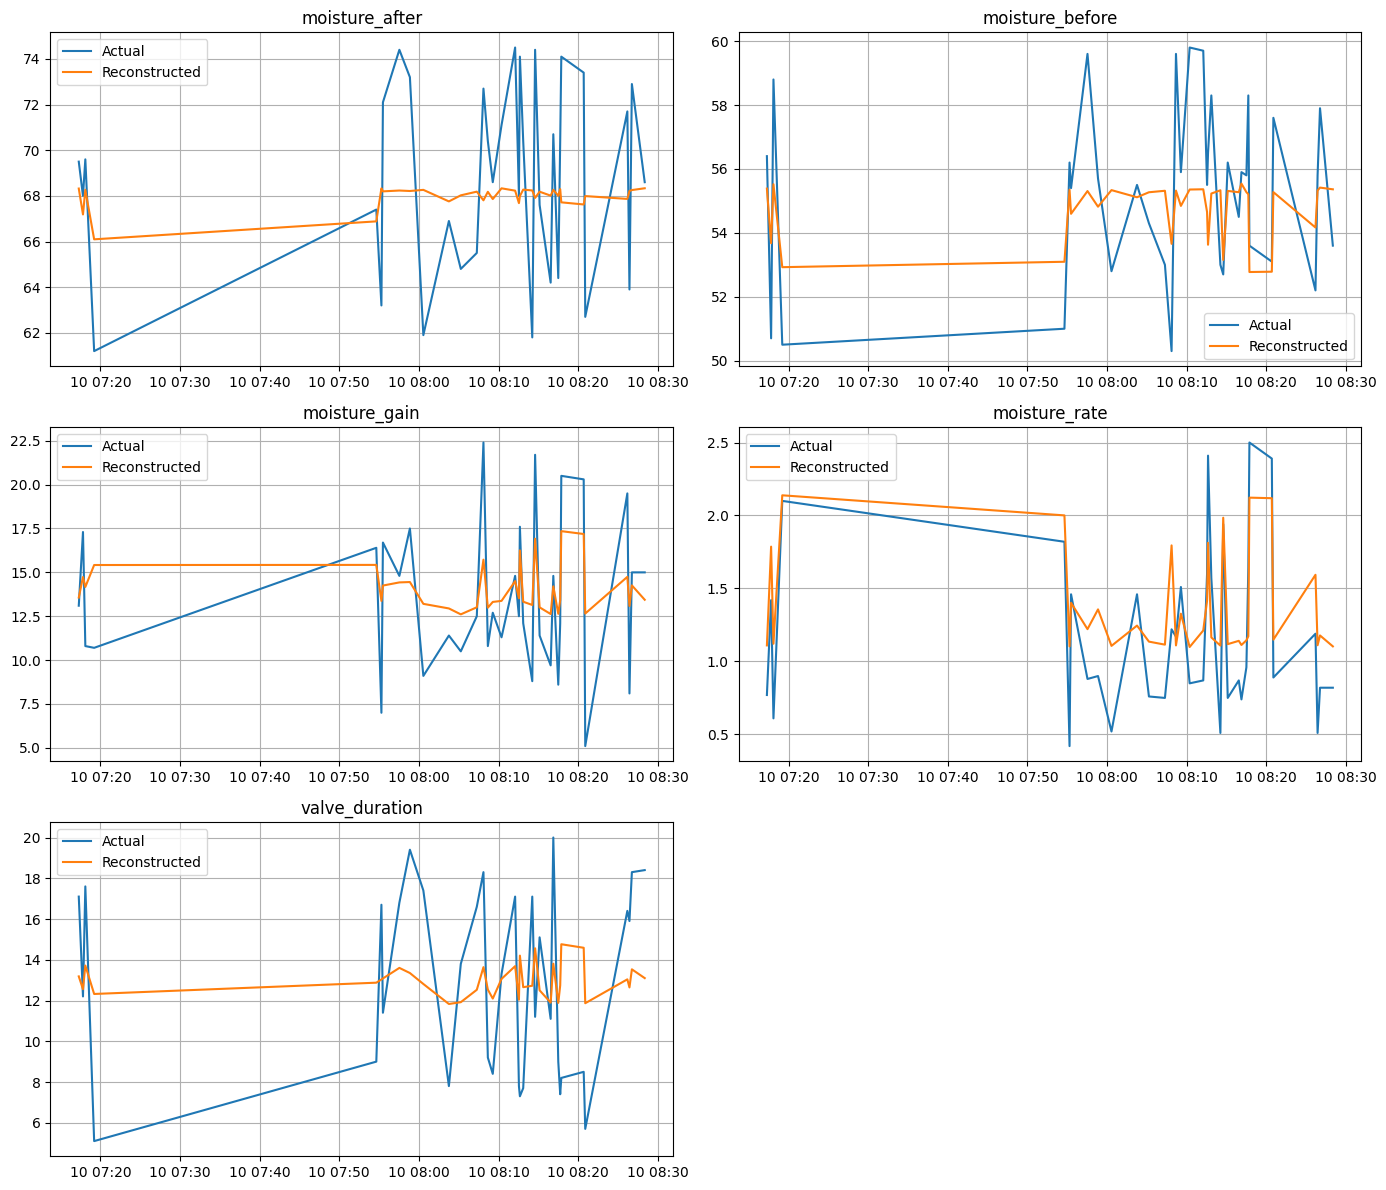

In [18]:
# Visualize the actual vs reconstructed values for the test set
comparison_plot(df_test, df_test_recon)

### MSE Loss Graph

In [19]:
df_train_recon = pd.DataFrame(recon_train_loss, columns=['MSE Loss'], index=df_train.index)
df_train_recon['Fault'] = df_train_recon['MSE Loss'] > threshold
df_train_recon.head()

,MSE Loss,Fault
time,,
2026-06-10 08:30:23.537,1.029118,False
2026-06-10 08:30:11.736,0.912814,False
2026-06-10 08:30:01.435,0.525004,False
2026-06-10 08:29:51.934,0.554008,False
2026-06-10 08:29:32.934,0.729388,False


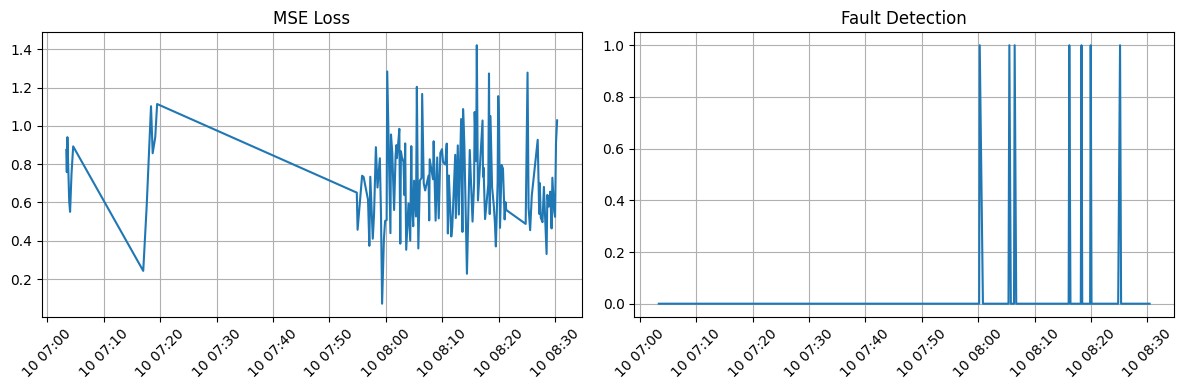

In [32]:
# Gabungkan grafik MSE Loss dan Fault Detection dalam satu figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_train_recon['MSE Loss'], label='Actual')
axes[0].set_title('MSE Loss')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(df_train_recon['Fault'], label='Fault')
axes[1].set_title('Fault Detection')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()